In [1]:
import sys
print(sys.path)

['C:\\ProgramData\\anaconda3\\python313.zip', 'C:\\ProgramData\\anaconda3\\DLLs', 'C:\\ProgramData\\anaconda3\\Lib', 'C:\\ProgramData\\anaconda3', '', 'C:\\Users\\hossam\\AppData\\Roaming\\Python\\Python313\\site-packages', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\win32', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\win32\\lib', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\Pythonwin']


In [2]:
import mysql
print(mysql.__file__)

C:\Users\hossam\AppData\Roaming\Python\Python313\site-packages\mysql\__init__.py


In [3]:
import mysql.connector
print(mysql.connector.__file__)

C:\Users\hossam\AppData\Roaming\Python\Python313\site-packages\mysql\connector\__init__.py


In [4]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="123099",
    database="telecom_clean"
)

print(conn.is_connected())

True


In [5]:
services = pd.read_sql("SELECT * FROM Services;", conn)
services.head()

C:\Users\hossam\AppData\Local\Temp\ipykernel_17604\3841492869.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  services = pd.read_sql("SELECT * FROM Services;", conn)


,Service_ID,Customer_ID,Referred_a_Friend,Number_of_Referrals,Tenure_in_Months,Offer,Phone_Service,Avg_Monthly_Long_Distance_Charges,Multiple_Lines,Internet_Type,...,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
0,IJKDQVSWH3522,8779-QRDMV,No,0,1,No Offer,No,0.00,0,DSL,...,No,Month-To-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20.0,0.00,59.65
1,BFKMZJAIE2285,7495-OOKFY,Yes,1,8,Offer E,Yes,48.85,1,Fiber Optic,...,Yes,Month-To-Month,Yes,Credit Card,80.65,633.30,0.00,0.0,390.80,1024.10
2,EIMVJQBMT7187,1658-BYGOY,No,0,18,Offer D,Yes,11.33,1,Fiber Optic,...,Yes,Month-To-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0.0,203.94,1910.88
3,EROZQXDUU4979,4598-XLKNJ,Yes,1,25,Offer C,Yes,19.76,0,Fiber Optic,...,Yes,Month-To-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0.0,494.00,2995.07
4,GEEYSJUHY6991,4846-WHAFZ,Yes,1,37,Offer C,Yes,6.33,1,Fiber Optic,...,Yes,Month-To-Month,Yes,Bank Withdrawal,76.50,286815.00,0.00,0.0,234.21,3102.36


In [6]:
status = pd.read_sql("SELECT * FROM Status;", conn)
status.head()

C:\Users\hossam\AppData\Local\Temp\ipykernel_17604\1430837296.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  status = pd.read_sql("SELECT * FROM Status;", conn)


,Status_ID,Customer_ID,Satisfaction_Score,Customer_Status,ChurNo_Label,Churn_Score,CLTV
0,SWSORB1252,8779-QRDMV,3,Churned,Yes,91,5433
1,SNAEQA8572,7495-OOKFY,3,Churned,Yes,69,5302
2,LMBQNN3714,1658-BYGOY,2,Churned,Yes,81,3179
3,VRZYZI9978,4598-XLKNJ,2,Churned,Yes,88,5337
4,FDNAKX1688,4846-WHAFZ,2,Churned,Yes,67,2793


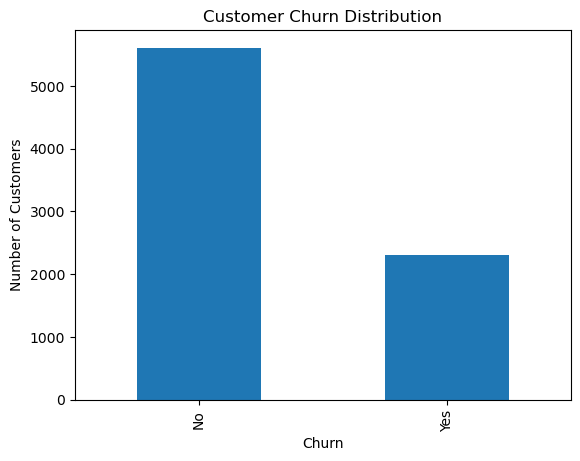

In [9]:
import matplotlib.pyplot as plt

status["ChurNo_Label"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [10]:
status.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8183 entries, 0 to 8182
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Status_ID           8183 non-null   object
 1   Customer_ID         8183 non-null   object
 2   Satisfaction_Score  8183 non-null   int64 
 3   Customer_Status     8060 non-null   object
 4   ChurNo_Label        7917 non-null   object
 5   Churn_Score         8183 non-null   int64 
 6   CLTV                8183 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 447.6+ KB


In [11]:
status.isnull().sum()

Status_ID               0
Customer_ID             0
Satisfaction_Score      0
Customer_Status       123
ChurNo_Label          266
Churn_Score             0
CLTV                    0
dtype: int64

In [12]:
status["Customer_Status"].value_counts(dropna=False)

Customer_Status
Stayed     5211
Churned    2364
Joined      485
None        123
Name: count, dtype: int64

In [13]:
status["ChurNo_Label"].value_counts(dropna=False)

ChurNo_Label
No      5609
Yes     2308
None     266
Name: count, dtype: int64

In [14]:
status["Customer_Status"].mode()

0    Stayed
Name: Customer_Status, dtype: object

In [15]:
status["ChurNo_Label"].mode()

0    No
Name: ChurNo_Label, dtype: object

In [17]:
status["Customer_Status"] = status["Customer_Status"].fillna(
    status["Customer_Status"].mode()[0]
)

status["ChurNo_Label"] = status["ChurNo_Label"].fillna(
    status["ChurNo_Label"].mode()[0]
)

In [18]:
status.isnull().sum()

Status_ID             0
Customer_ID           0
Satisfaction_Score    0
Customer_Status       0
ChurNo_Label          0
Churn_Score           0
CLTV                  0
dtype: int64

In [19]:
status = status.apply(
    lambda col: col.str.strip() if col.dtype == "object" else col
)

In [20]:
status.duplicated().sum()

np.int64(1000)

In [21]:
status.drop_duplicates(inplace=True)

In [22]:
status.dtypes

Status_ID             object
Customer_ID           object
Satisfaction_Score     int64
Customer_Status       object
ChurNo_Label          object
Churn_Score            int64
CLTV                   int64
dtype: object

In [23]:
status["Customer_Status"].unique()

array(['Churned', 'Stayed', 'Joined'], dtype=object)

In [24]:
status["ChurNo_Label"].unique()

array(['Yes', 'No'], dtype=object)

In [25]:
services.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5319 entries, 0 to 5318
Data columns (total 28 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Service_ID                         5319 non-null   object 
 1   Customer_ID                        5318 non-null   object 
 2   Referred_a_Friend                  5319 non-null   object 
 3   Number_of_Referrals                5319 non-null   int64  
 4   Tenure_in_Months                   5319 non-null   int64  
 5   Offer                              5319 non-null   object 
 6   Phone_Service                      5319 non-null   object 
 7   Avg_Monthly_Long_Distance_Charges  5319 non-null   float64
 8   Multiple_Lines                     5306 non-null   object 
 9   Internet_Type                      5319 non-null   object 
 10  Avg_Monthly_GB_Download            5319 non-null   int64  
 11  Online_Security                    5319 non-null   objec

In [26]:
services.isnull().sum()

Service_ID                             0
Customer_ID                            1
Referred_a_Friend                      0
Number_of_Referrals                    0
Tenure_in_Months                       0
Offer                                  0
Phone_Service                          0
Avg_Monthly_Long_Distance_Charges      0
Multiple_Lines                        13
Internet_Type                          0
Avg_Monthly_GB_Download                0
Online_Security                        0
Online_Backup                          0
Device_Protection_Plan                 0
Premium_Tech_Support                   0
Streaming_TV                          11
Streaming_Movies                       0
Streaming_Music                        0
Unlimited_Data                         0
Contract                               0
Paperless_Billing                      0
Payment_Method                       125
Monthly_Charge                        58
Total_Charges                          0
Total_Refunds   

In [27]:
services.duplicated().sum()

np.int64(1)

In [28]:
services.drop_duplicates(inplace=True)

In [29]:
services = services.apply(
    lambda col: col.str.strip() if col.dtype == "object" else col
)

In [30]:
services.select_dtypes(include="object").columns

Index(['Service_ID', 'Customer_ID', 'Referred_a_Friend', 'Offer',
       'Phone_Service', 'Multiple_Lines', 'Internet_Type', 'Online_Security',
       'Online_Backup', 'Device_Protection_Plan', 'Premium_Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data',
       'Contract', 'Paperless_Billing', 'Payment_Method'],
      dtype='object')

In [31]:
for col in services.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(services[col].unique()[:10])


Service_ID
['IJKDQVSWH3522' 'BFKMZJAIE2285' 'EIMVJQBMT7187' 'EROZQXDUU4979'
 'GEEYSJUHY6991' 'UEHAPZRZX9455' 'HKSJPZQQO3668' 'SGNKYLZPV6432'
 'CQIFHUNEW9871' 'XIOWKBRNN4393']

Customer_ID
['8779-QRDMV' '7495-OOKFY' '1658-BYGOY' '4598-XLKNJ' '4846-WHAFZ'
 '4412-YLTKF' '0390-DCFDQ' '2656-FMOKZ' '2070-FNEXE' '0094-OIFMO']

Referred_a_Friend
['No' 'Yes']

Offer
['No Offer' 'Offer E' 'Offer D' 'Offer C' 'Offer B' 'Offer A']

Phone_Service
['No' 'Yes']

Multiple_Lines
['0' '1' None]

Internet_Type
['DSL' 'Fiber Optic' 'Cable' 'No Internet']

Online_Security
['No' 'Yes']

Online_Backup
['No' 'Yes']

Device_Protection_Plan
['Yes' 'No']

Premium_Tech_Support
['No' 'Yes']

Streaming_TV
['No' 'Yes' None]

Streaming_Movies
['Yes' 'No']

Streaming_Music
['No' 'Yes']

Unlimited_Data
['No' 'Yes']

Contract
['Month-To-Month' 'One Year' 'Two Year']

Paperless_Billing
['Yes' 'No']

Payment_Method
['Bank Withdrawal' 'Credit Card' 'Mailed Check' None]


In [32]:
for col in services.select_dtypes(include="object").columns:
    services[col] = services[col].str.strip().str.title()

In [33]:
services.isnull().sum()

Service_ID                             0
Customer_ID                            1
Referred_a_Friend                      0
Number_of_Referrals                    0
Tenure_in_Months                       0
Offer                                  0
Phone_Service                          0
Avg_Monthly_Long_Distance_Charges      0
Multiple_Lines                        13
Internet_Type                          0
Avg_Monthly_GB_Download                0
Online_Security                        0
Online_Backup                          0
Device_Protection_Plan                 0
Premium_Tech_Support                   0
Streaming_TV                          11
Streaming_Movies                       0
Streaming_Music                        0
Unlimited_Data                         0
Contract                               0
Paperless_Billing                      0
Payment_Method                       125
Monthly_Charge                        58
Total_Charges                          0
Total_Refunds   

In [34]:
services.dropna(subset=["Customer_ID"], inplace=True)

In [35]:
services["Multiple_Lines"].fillna(
    services["Multiple_Lines"].mode()[0],
    inplace=True
)

C:\Users\hossam\AppData\Local\Temp\ipykernel_17604\4226288648.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  services["Multiple_Lines"].fillna(


In [36]:
services["Streaming_TV"].fillna(
    services["Streaming_TV"].mode()[0],
    inplace=True
)

C:\Users\hossam\AppData\Local\Temp\ipykernel_17604\274555018.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  services["Streaming_TV"].fillna(


In [37]:
services.isnull().sum()

Service_ID                             0
Customer_ID                            0
Referred_a_Friend                      0
Number_of_Referrals                    0
Tenure_in_Months                       0
Offer                                  0
Phone_Service                          0
Avg_Monthly_Long_Distance_Charges      0
Multiple_Lines                         0
Internet_Type                          0
Avg_Monthly_GB_Download                0
Online_Security                        0
Online_Backup                          0
Device_Protection_Plan                 0
Premium_Tech_Support                   0
Streaming_TV                           0
Streaming_Movies                       0
Streaming_Music                        0
Unlimited_Data                         0
Contract                               0
Paperless_Billing                      0
Payment_Method                       125
Monthly_Charge                        58
Total_Charges                          0
Total_Refunds   

In [38]:
services.drop_duplicates(inplace=True)

In [39]:
services = services.apply(
    lambda col: col.str.strip() if col.dtype == "object" else col
)

In [40]:
for col in services.select_dtypes(include="object"):
    services[col] = services[col].str.title()

In [41]:
services["Payment_Method"].fillna(
    services["Payment_Method"].mode()[0],
    inplace=True
)

services["Monthly_Charge"].fillna(
    services["Monthly_Charge"].median(),
    inplace=True
)

C:\Users\hossam\AppData\Local\Temp\ipykernel_17604\1729449741.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  services["Payment_Method"].fillna(
C:\Users\hossam\AppData\Local\Temp\ipykernel_17604\1729449741.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when d

In [42]:
services.isnull().sum()

Service_ID                           0
Customer_ID                          0
Referred_a_Friend                    0
Number_of_Referrals                  0
Tenure_in_Months                     0
Offer                                0
Phone_Service                        0
Avg_Monthly_Long_Distance_Charges    0
Multiple_Lines                       0
Internet_Type                        0
Avg_Monthly_GB_Download              0
Online_Security                      0
Online_Backup                        0
Device_Protection_Plan               0
Premium_Tech_Support                 0
Streaming_TV                         0
Streaming_Movies                     0
Streaming_Music                      0
Unlimited_Data                       0
Contract                             0
Paperless_Billing                    0
Payment_Method                       0
Monthly_Charge                       0
Total_Charges                        0
Total_Refunds                        0
Total_Extra_Data_Charges 

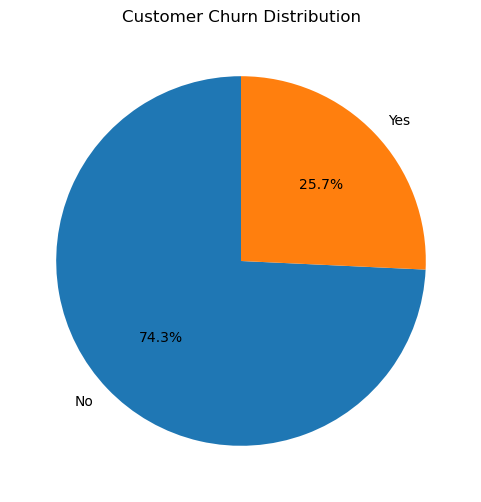

In [48]:
plt.figure(figsize=(6,6))

status["ChurNo_Label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.show()

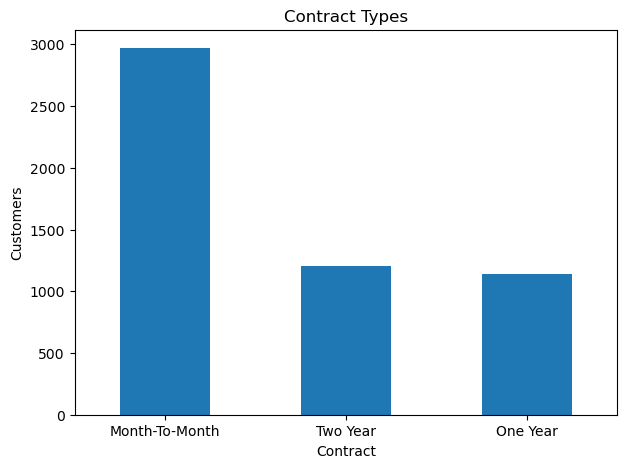

In [49]:
plt.figure(figsize=(7,5))

services["Contract"].value_counts().plot(
    kind="bar"
)

plt.title("Contract Types")
plt.xlabel("Contract")
plt.ylabel("Customers")
plt.xticks(rotation=0)
plt.show()

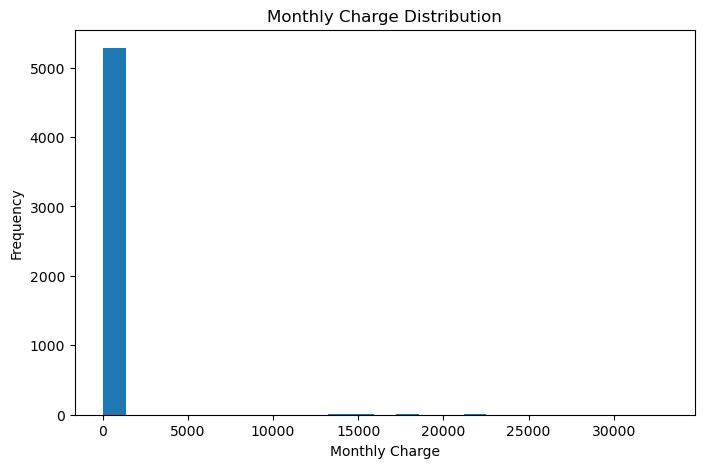

In [50]:
plt.figure(figsize=(8,5))

plt.hist(services["Monthly_Charge"], bins=25)

plt.title("Monthly Charge Distribution")
plt.xlabel("Monthly Charge")
plt.ylabel("Frequency")
plt.show()

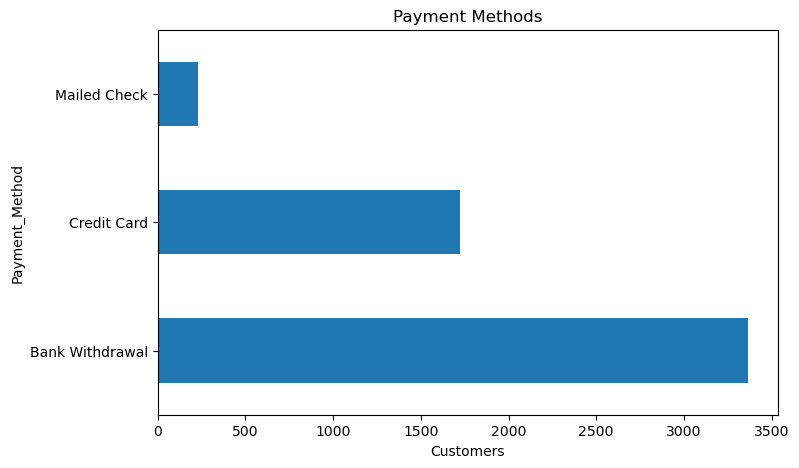

In [51]:
plt.figure(figsize=(8,5))

services["Payment_Method"].value_counts().plot(
    kind="barh"
)

plt.title("Payment Methods")
plt.xlabel("Customers")
plt.show()

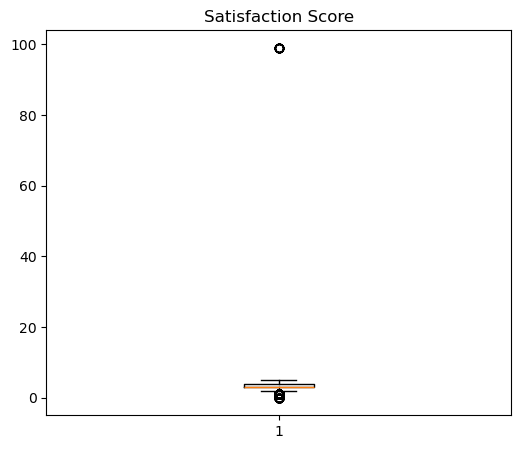

In [52]:
plt.figure(figsize=(6,5))

plt.boxplot(status["Satisfaction_Score"])

plt.title("Satisfaction Score")
plt.show()

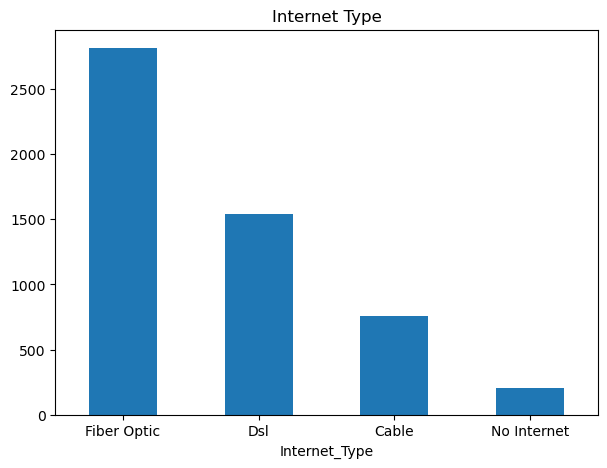

In [53]:
plt.figure(figsize=(7,5))

services["Internet_Type"].value_counts().plot(
    kind="bar"
)

plt.title("Internet Type")
plt.xticks(rotation=0)
plt.show()

<Figure size 800x500 with 0 Axes>

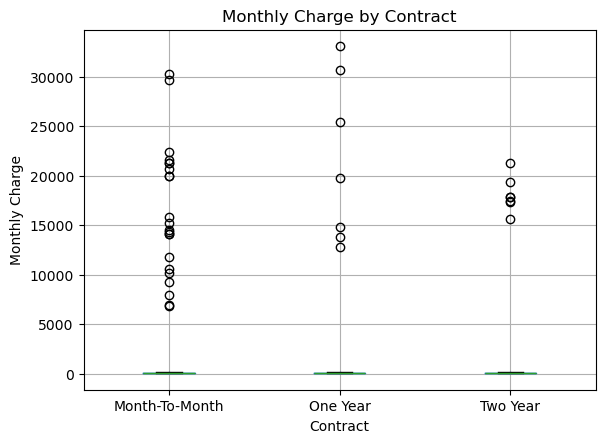

In [54]:
plt.figure(figsize=(8,5))

services.boxplot(column="Monthly_Charge", by="Contract")

plt.title("Monthly Charge by Contract")
plt.suptitle("")
plt.xlabel("Contract")
plt.ylabel("Monthly Charge")
plt.show()

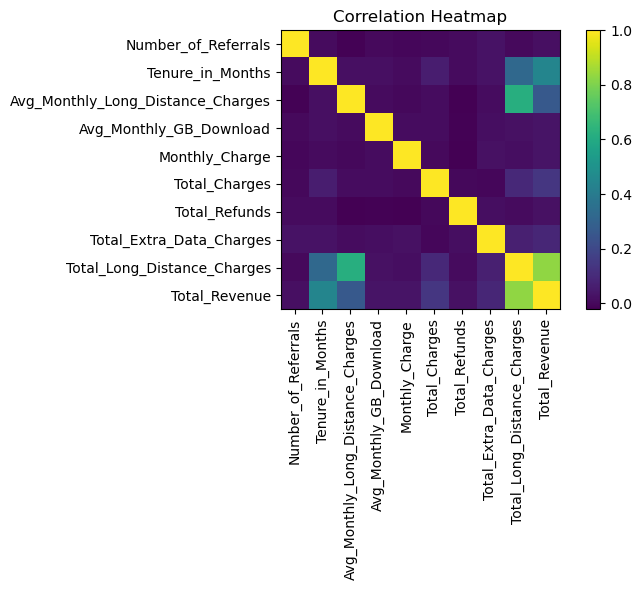

In [55]:
import matplotlib.pyplot as plt

corr = services.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()